# XGBoost - Modelo Aplicado a demanda energética Alemania

Aplicación del modelo XGBoost a la predicción valores de consumo de demanda energética en Alemania. Primero se importan las librerías requeridas (CORREGIR LA MONOGRAFÏA)

In [1]:

import xgboost

# procesamiento
import pandas as pd
import numpy as np
import holidays
import json

# ml, procesamiento
#import sklearn

from sklearn.model_selection import TimeSeriesSplit
#from sklearn.model_selection import train_test_split # no se requiere
from sklearn.preprocessing import MinMaxScaler 
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.model_selection import GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# optimización, warnings
import optuna
import warnings
import optuna.visualization as vis
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split

# visual
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
#plt.style.use("seaborn-v0_8-darkgrid")
#sns.set_palette("viridis")

# semilla para reproductibilidad
# configuración de reproductbilidad
np.random.seed(42)
from optuna.samplers import TPESampler # reproductibilidad con optuna

c:\Users\JUAN DAVID\Desktop\maestria docs\codigo python\venv_tesis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Se cargan los valores de consumo a nivel semanal. La semana en este caso se toma el primer día como lunes, es fecha muestra el promedio de la semana y se formatean las fechas en formato date. El orden de las observaciones es de $10^6$

In [2]:
date_close =  pd.read_csv("../../../data/csv/EC_GER_Weekly.csv")
df_data_close = pd.DataFrame(date_close.copy()) # copia del df de precios de cierre como df
df_data_close["Start date"] = pd.to_datetime(df_data_close["Start date"])
df_data_close = df_data_close.sort_values(by="Start date", ascending=True) # se ordena por fecha ascendente
df_data_close.head()


,Start date,value
0,2015-01-05,1.240580e+06
1,2015-01-12,1.465239e+06
2,2015-01-19,1.479857e+06
3,2015-01-26,1.516270e+06
4,2015-02-02,1.507588e+06


Se grafican la serie a partir del df anterior

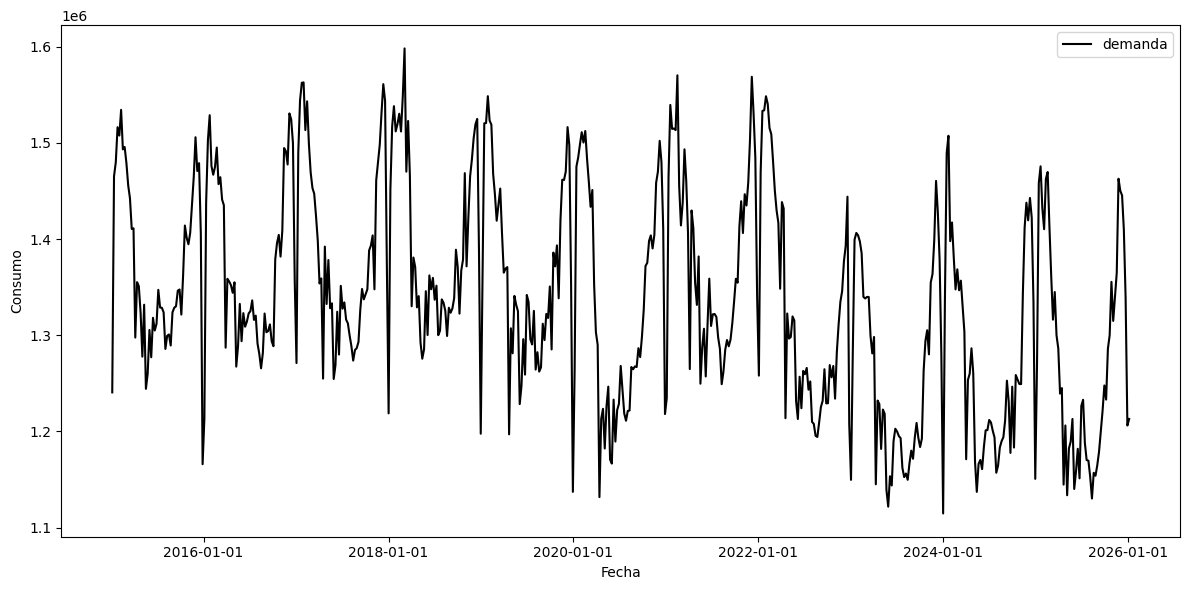

In [3]:
# se grafican los datos de consumo de forma semanal
plt.figure(figsize=(12,6))
plt.plot(df_data_close["Start date"], df_data_close["value"], label="demanda", color="black")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
#plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

Se definen variables generales a tener en cuenta en el df a partir de la fecha: temporalidades: año, mes, día, día de la semana, cuatrimestre, con el fin de definir el espacio de variables de entrada del modelo

In [4]:
def get_data_times(df, columnName):
    df_copy = df.copy()
    df_copy["year"] = df_copy[columnName].apply(lambda x: x.year)
    df_copy["month"] = df_copy[columnName].apply(lambda x: x.month)
    #df_copy["day"] = df_copy[columnName].apply(lambda x: x.day)
    #df_copy["dayofweek"] = df_copy[columnName].apply(lambda x: x.dayofweek)
    df_copy["quarter"] = df_copy[columnName].apply(lambda x: x.quarter)
    return df_copy

df_data_close = get_data_times(df_data_close, columnName="Start date")
df_data_close.head()

,Start date,value,year,month,quarter
0,2015-01-05,1.240580e+06,2015,1,1
1,2015-01-12,1.465239e+06,2015,1,1
2,2015-01-19,1.479857e+06,2015,1,1
3,2015-01-26,1.516270e+06,2015,1,1
4,2015-02-02,1.507588e+06,2015,2,1


Se añaden otras variables como el lag anterior y media móvil en distintos periodos. La siguiente función recibe como argumentos un array con los nombres de las columnas y un array con los rezagos a calcular

In [5]:
def make_df_full_lags(df, lags, variables):
    df_copy = df.copy()
    for variable in variables:
        for lag in lags:
            df_copy[f"{variable}_lag_{str(lag)}"] = df_copy[f"{variable}"].shift(lag)

    return df_copy

variables = [col for col in df_data_close.columns if ("value" in col ) ]
# rezagos por días
# lags = [1,2,7,15,30,60,90]

# rezagos por semanas
lags = [1, 2, 3, 4, 8, 12, 52]
df_data_close = make_df_full_lags(df_data_close, lags, variables).dropna()
df_data_close = df_data_close.reset_index(drop=True)
df_data_close.head()

,Start date,value,year,month,quarter,value_lag_1,value_lag_2,value_lag_3,value_lag_4,value_lag_8,value_lag_12,value_lag_52
0,2016-01-04,1.213233e+06,2016,1,1,1.165943e+06,1.404996e+06,1.478872e+06,1.470758e+06,1.406408e+06,1.362325e+06,1.240580e+06
1,2016-01-11,1.437911e+06,2016,1,1,1.213233e+06,1.165943e+06,1.404996e+06,1.478872e+06,1.435765e+06,1.414048e+06,1.465239e+06
2,2016-01-18,1.502718e+06,2016,1,1,1.437911e+06,1.213233e+06,1.165943e+06,1.404996e+06,1.464466e+06,1.401533e+06,1.479857e+06
3,2016-01-25,1.528752e+06,2016,1,1,1.502718e+06,1.437911e+06,1.213233e+06,1.165943e+06,1.505831e+06,1.394589e+06,1.516270e+06
4,2016-02-01,1.475937e+06,2016,2,1,1.528752e+06,1.502718e+06,1.437911e+06,1.213233e+06,1.470758e+06,1.406408e+06,1.507588e+06


Cálculo de medias móviles para diversos periodos, que funcionan como variables de entrada adicionales

In [6]:
# medias móviles de los precios de cierre: se crea una función para que tome las medias móviles de determinados
# días. Se toman estas medias moviles para los precios anteriores
def make_df_full_averages(df, vars_list, ma_periods, dropna=True, overwrite=False):
    df_copy = df.copy()

    # solo permitir variables originales (sin _lag_ ni _ma_)
    clean_vars = [
        v for v in vars_list
        if v in df_copy.columns and "_lag_" not in v and "_ma_" not in v
    ]

    missing = [v for v in vars_list if v not in df_copy.columns]
    if missing:
        raise ValueError(f"Estas columnas no existen: {missing}") # valida si las variables requeridas existen

    for variable in clean_vars:
        for period in ma_periods:
            name = f"{variable}_ma_{period}" # nombre de columna para cálculo de MA de variable

            if (name in df_copy.columns) and (not overwrite):
                continue

            df_copy[name] = (
                df_copy[variable]
                .shift(1)  # evita leakage, dado que se toma desde la posición t-1 hacia atras
                .rolling(window=period)
                .mean()
            )

    if dropna:
        df_copy = df_copy.dropna().reset_index(drop=True)

    return df_copy

# periodos para ma por días
# ma_periods = [7, 15, 30, 60, 90]

# periodos ma por semanas
ma_periods = [
    2, # dos semanas desde la anterior
    3, # tres semanas desde la anterior
    4, # 4 semanas desde la anterior (desde la ultima semana, un mes)
    8, # 8 semanas desde la anterior (desde la ultima semana, dos meses)
    12, # 12 semanas desde la anterior (desde la ultima semana, tres meses)
    16 # 16 semanas desde la anterior (desde la última semana, 4 meses)
]

df_data_close = make_df_full_averages(
    df_data_close,
    vars_list=variables,
    ma_periods=ma_periods
)

df_data_close.head()

,Start date,value,year,month,quarter,value_lag_1,value_lag_2,value_lag_3,value_lag_4,value_lag_8,value_lag_12,value_lag_52,value_ma_2,value_ma_3,value_ma_4,value_ma_8,value_ma_12,value_ma_16
0,2016-04-25,1.344112e+06,2016,4,2,1.352060e+06,1.355867e+06,1.358682e+06,1.287062e+06,1.457129e+06,1.475937e+06,1.323606e+06,1.353963e+06,1.355536e+06,1.338418e+06,1.393927e+06,1.422028e+06,1.421685e+06
1,2016-05-02,1.354987e+06,2016,5,2,1.344112e+06,1.352060e+06,1.355867e+06,1.358682e+06,1.464299e+06,1.466870e+06,1.277736e+06,1.348086e+06,1.350679e+06,1.352680e+06,1.379800e+06,1.411043e+06,1.429865e+06
2,2016-05-09,1.267394e+06,2016,5,2,1.354987e+06,1.344112e+06,1.352060e+06,1.355867e+06,1.441140e+06,1.475012e+06,1.331730e+06,1.349550e+06,1.350386e+06,1.351756e+06,1.366136e+06,1.401719e+06,1.424682e+06
3,2016-05-16,1.288666e+06,2016,5,2,1.267394e+06,1.354987e+06,1.344112e+06,1.352060e+06,1.435180e+06,1.495105e+06,1.244288e+06,1.311191e+06,1.322164e+06,1.329638e+06,1.344418e+06,1.384418e+06,1.409974e+06
4,2016-05-23,1.332559e+06,2016,5,2,1.288666e+06,1.267394e+06,1.354987e+06,1.344112e+06,1.287062e+06,1.457129e+06,1.259924e+06,1.278030e+06,1.303682e+06,1.313790e+06,1.326104e+06,1.367215e+06,1.394969e+06


Se seleccionan las variables que serán las variables de entrada del modelo, filtrando por aquellas que no sean $\texttt{value}$, que es la variable a predecir 

In [7]:
# selecicon de variables
target = ["value"]
features = [col for col in df_data_close.columns if (col not in target)]
features

['Start date',
 'year',
 'month',
 'quarter',
 'value_lag_1',
 'value_lag_2',
 'value_lag_3',
 'value_lag_4',
 'value_lag_8',
 'value_lag_12',
 'value_lag_52',
 'value_ma_2',
 'value_ma_3',
 'value_ma_4',
 'value_ma_8',
 'value_ma_12',
 'value_ma_16']

Se esquematizan los datos como un problema de aprendizaje supervisado: X es el array de features, y es el array de valores (columna value, que es la que se quiere predecir)

In [8]:
X = df_data_close[features].copy()
X = X.set_index("Start date")
y = df_data_close[target]

# se realiza separación train/test, el train se usa para determinar el mejor modelo en función de una métrica de error
# X_folds: conjunto de datos para entrenar el modelo por folds
# y_folds: conjunto de validacion de train

# X_val: conjunto de val de features
#y val: conjunto de val de valores
percentage = 0.9 # porcentaje conjunto folds

folds_data_size = int(len(df_data_close) * percentage) # tamaño conjunto folds

X_folds = X.iloc[:folds_data_size]
y_folds = y.iloc[:folds_data_size]

X_val = X.iloc[folds_data_size:]
y_val = y.iloc[folds_data_size:]

Se grafican los datos Folds/Val

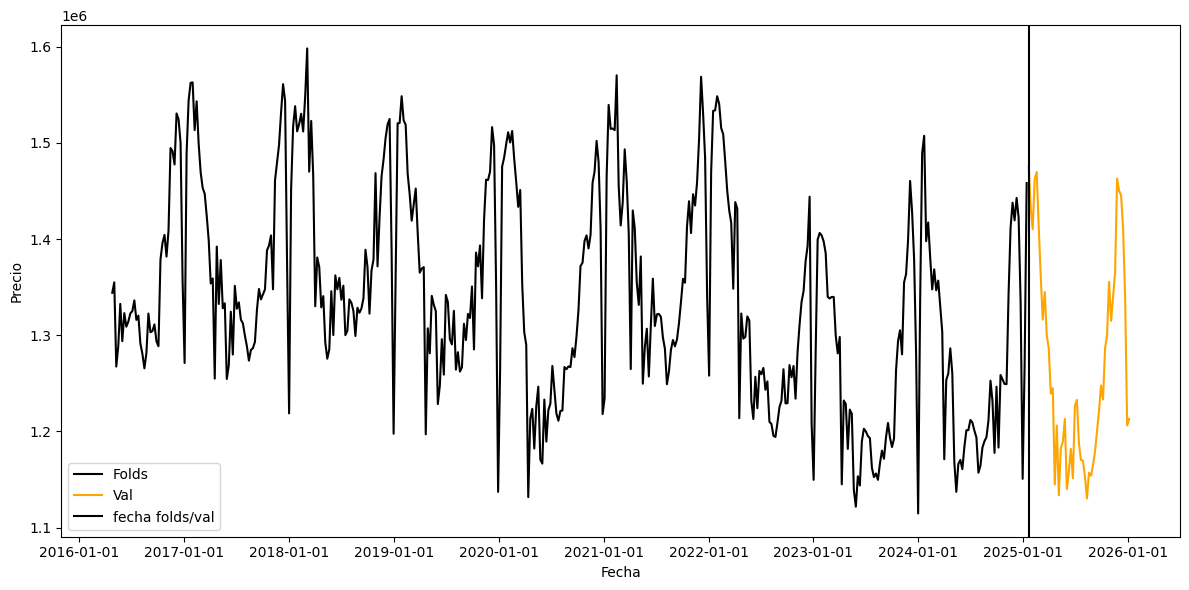

In [9]:
plt.figure(figsize=(12,6))
plt.plot(X_folds.index, y_folds, label="Folds", color="black")
plt.plot(X_val.index, y_val, label="Val", color="orange")
plt.axvline(X_val.index[0], label="fecha folds/val", color="black")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
#plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

### Creación de Folds
Para el conjunto de datos X_Folds se definen una serie de "particiones" que ayudarán a determinar si el modelo encontrado se ajusta de forma consistente en diversas franjas de tiempo, ayudando a evitar inferir correlaciones espurias 

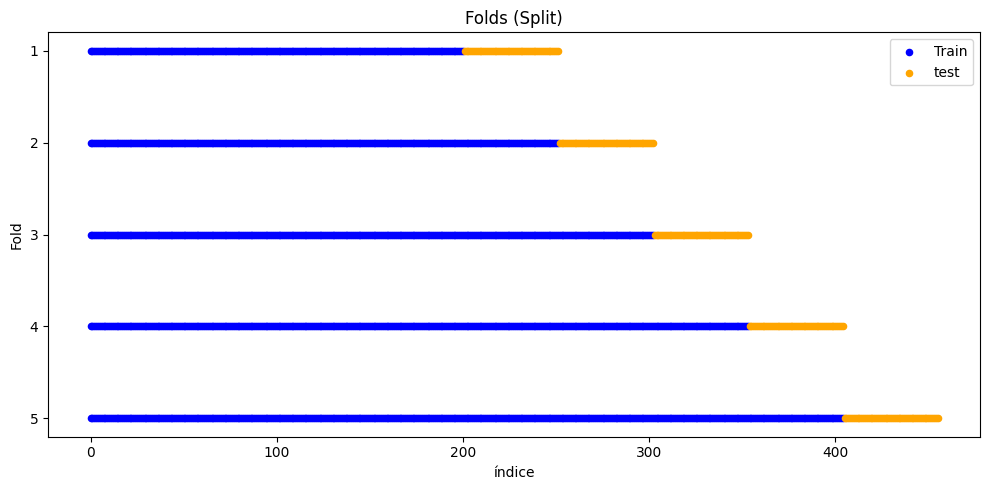

In [10]:
# visualizacion de los folds 
# se muestra de forma visual como funcionan los folds
# si no se define el tamaño de test, en la primera iteracion se toma igual cantidad de datos para train que para test
# por eso se toman los folds de prueba como de la longitud de datos de validación
size_test = int(len(X_val))
gap = 0 # distancia (cantidad de observaciones) que se deja entre train y test
n_splits = 5 # cantidad de folds
tscv = TimeSeriesSplit(
    n_splits=n_splits,
    test_size=size_test, 
)

folds, indexes, types = [], [], []
fig, ax = plt.subplots(figsize=(10,5))
for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_folds)):
    # datos de entrenamiento
    fold_plot = fold_idx + 1
    ax.scatter(
        train_idx,
        [fold_plot] * len(train_idx),
        label="Train" if fold_idx == 0 else '',
        s=20, 
        color="blue"
    )
    # datos de prueba

    ax.scatter(
        test_idx,
        [fold_plot] * len(test_idx),
        label="test" if fold_idx == 0 else '',
        s=20,
        color="orange"
    )

ax.set_title("Folds (Split)")
ax.set_xlabel("índice")
ax.set_ylabel("Fold")

# invertir eje
#ax.invert_xaxis()
ax.legend()
ax.set_yticks(range(1, n_splits + 1))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Función para instanciar el modelo

In [11]:
# función de creación del modelo 
def build_xgboost_regressor(**params):
    # puedes establecer valores por defecto si faltan
    params.setdefault("objective", "reg:squarederror")
    params.setdefault("tree_method", "exact")
    params.setdefault("random_state", 42)

    model = xgboost.XGBRegressor(**params)
    return model


# Función de optimización

Mediante el uso de Optuna (una librería basada en técnicas de optimización bayesiana secuencial) se define una función de optimización que utiliza validación cruzada temporal para minimizar una métrica de error (en este caso, el MAPE*).

La función está dada de la siguiente forma: primero, se definen los hiperparámetros de la rnn: número de rezagos, unidades recurrentes, tasa de aprendizaje, tamaño de lote y número de épocas.   Para cada uno de estos parámetros se especifican rangos o conjuntos discretos de valores que Optuna explorará con el fin de encontrar la combinación que minimice el error promedio.

Posteriormente, se inicializan listas que almacenarán las métricas de evaluación obtenidas en cada fold (MAPE, MAE y RMSE).  
Durante cada iteración del proceso de validación cruzada, se realiza lo siguiente:
0. se definen los conjuntos train/test de acuerdo con ese fold
1. Se instancia un nuevo modelo XGBoost con el conjunto de hiperparámetros seleccionados para el trial actual.  
2. Se entrena el modelo sobre el conjunto de entrenamiento definido para ese fold.  
3. Se evalúa el modelo sobre el conjunto de prueba correspondiente, calculando las métricas de error.  

Este proceso se repite para los *k* folds (en este caso, 5), produciendo un conjunto de errores por fold:

- Fold₁ → MAPE₁  
- Fold₂ → MAPE₂  
- Fold₃ → MAPE₃  
- Fold₄ → MAPE₄  
- Fold₅ → MAPE₅  

Así se obtiene el MAPE promedio de los cinco folds:$$ \text{MAPE}_{prom} = \frac{1}{5} \sum_{i=1}^{5} \text{MAPE}_i $$

Este valor se devuelve como resultado de la función objetivo, y representa el desempeño promedio del modelo bajo ese conjunto de hiperparámetros. Optuna repite este proceso en múltiples trials, cada uno con una combinación diferente de hiperparámetros, y selecciona el conjunto que minimiza el MAPE promedio obtenido.


In [12]:
# validación tamaños conjuntos folds / val
print(f"cantidad datos folds: {len(X_folds)}")
print(f"cantidad datos val: {len(X_val)}")

cantidad datos folds: 456
cantidad datos val: 51


In [13]:
def objective(trial):
    # Parámetros del modelo
    #lag = trial.suggest_categorical("lag", [1, 2, 7, 15, 30, 90])
    params = {
        # cantidad arboles
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        # profundidad de cada arbol
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        # tasa de aprendizaje
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        # longitud minima
        "min_child_weight": trial.suggest_float("min_child_weight", 5.0, 15.0),
        # umbral de ganancia
        "gamma": trial.suggest_float("gamma", 1e-3, 1.0),
        # parametro de regresión
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 5.0),
        #parametro de regresión
        "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 5.0),
        # cantidad de datos para la creación de los árboles
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        # función objetivo
        "objective": "reg:squarederror",
        # metodo de creación de particiones
        "tree_method": "exact",
        # semilla para reproductibilidad
        "random_state": 42,
        "nthread":1
    }

    # Métricas a recolectar
    mapes, maes, rmses, smapes, variables = [], [], [], [], []
    importancias_por_fold = []

    # Validación cruzada temporal
    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_folds)):
        variables = {}

        # División train/test (sin escalado)
        X_train, X_test = X_folds.iloc[train_idx], X_folds.iloc[test_idx]
        y_train = y_folds.iloc[train_idx].values
        y_test  = y_folds.iloc[test_idx].values

        
        # Entrenamiento, prediccion y metricas 
        model = build_xgboost_regressor(**params)
        model.fit(
            X_train, 
            y_train,
            eval_set=[(X_test, y_test)],
            verbose=False
        )

        #Predicciones
        y_pred = model.predict(X_test)

        # Métricas de error
        mae  = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        smape_calc = MeanAbsolutePercentageError(symmetric=True) 
        smape = smape_calc(y_test, y_pred)

        # almacenado en arrays
        mapes.append(mape)
        maes.append(mae)
        rmses.append(rmse)
        smapes.append(smape)


        # almacenado - variables de importancia
        booster = model.get_booster()
        score = booster.get_score(importance_type='gain') # puntaje por ganancia, definicion

        # validar que se encuentren todas las variables
        score_full = {col: score.get(col, 0.0) for col in X_train.columns}

        # se normalizan las variables
        total = sum(score_full.values())
        if total > 0:
            score_norm = {k: v / total for k, v in score_full.items()}
        else:
            score_norm = score_full

        importancias_por_fold.append(score_norm)

        #for i  in range(len(X_train.columns)):
        #    variables[X.columns[i]] = model.feature_importances_[i]

        # Registro 
        trial.set_user_attr(f"fold_{fold_idx + 1}", {
            "mae": mae,
            "mape": mape,
            "rmse": rmse, 
            "smape": smape,
            f"importancia_variables_fold_{fold_idx + 1}": score_norm

        })
        # reporte métrica a optimizar
        trial.report(np.mean(mapes), step=fold_idx)

   
    # Función objetivo
    mean_mape = np.mean(mapes)
    median_mape = np.median(mapes)
    mean_smape = np.mean(smapes)
    mean_rmse = np.mean(rmses)
    mean_mae = np.mean(maes)

    df_importance = pd.DataFrame(importancias_por_fold)

    importance_mean = df_importance.mean().to_dict()
    trial.set_user_attr("importance_mean", importance_mean)

    
    # configuración atributos de usuario
    trial.set_user_attr("mape_mean", mean_mape)
    trial.set_user_attr("mape_median", median_mape)
    trial.set_user_attr("mae_mean", mean_mae)
    trial.set_user_attr("rmse_mean", mean_rmse)
    trial.set_user_attr("smape_mean", mean_smape)
    
    
    return float(mean_mape) 

print("Optimización con Optuna en curso...")
study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50, n_jobs=1)
best_params = study.best_params
print("Mejores parámetros encontrados:\n", best_params)

[I 2026-04-25 16:55:31,826] A new study created in memory with name: no-name-93a61278-eae0-4f47-b2c6-c7f0e4a2f1d9


Optimización con Optuna en curso...


[I 2026-04-25 16:55:35,775] Trial 0 finished with value: 0.039417871249763654 and parameters: {'n_estimators': 350, 'max_depth': 8, 'learning_rate': 0.07587945476302646, 'min_child_weight': 10.986584841970366, 'gamma': 0.1568626218019941, 'reg_lambda': 0.864373149647393, 'reg_alpha': 0.38460969962417735, 'subsample': 0.9464704583099741, 'colsample_bytree': 0.8404460046972835}. Best is trial 0 with value: 0.039417871249763654.
[I 2026-04-25 16:55:37,060] Trial 1 finished with value: 0.03848044054093508 and parameters: {'n_estimators': 483, 'max_depth': 3, 'learning_rate': 0.0972918866945795, 'min_child_weight': 13.324426408004218, 'gamma': 0.21312677156759788, 'reg_lambda': 0.990942339314793, 'reg_alpha': 0.9986820982818257, 'subsample': 0.7216968971838151, 'colsample_bytree': 0.8099025726528951}. Best is trial 1 with value: 0.03848044054093508.
[I 2026-04-25 16:55:38,273] Trial 2 finished with value: 0.03817218739758916 and parameters: {'n_estimators': 373, 'max_depth': 4, 'learning_ra

Mejores parámetros encontrados:
 {'n_estimators': 420, 'max_depth': 7, 'learning_rate': 0.04924728725460317, 'min_child_weight': 6.28181175558134, 'gamma': 0.5628956200652583, 'reg_lambda': 2.5631300054321633, 'reg_alpha': 3.6580607862443353, 'subsample': 0.7559702553281903, 'colsample_bytree': 0.6061659318733446}


Se extraen los resultados del mejor trial

In [14]:
# Extraer resultados del mejor trial
best_trial = study.best_trial
print("Mejor trial:", best_trial.number)
print("MAPE promedio:", best_trial.value)
print("Atributos guardados:")
print(best_trial.user_attrs)


Mejor trial: 24
MAPE promedio: 0.036752436711023274
Atributos guardados:
{'fold_1': {'mae': 54983.246498599445, 'mape': 0.04374231547365283, 'rmse': 69544.75815024755, 'smape': 0.04239966407231364, 'importancia_variables_fold_1': {'year': 0.021792568018975195, 'month': 0.06069077507121968, 'quarter': 0.03927680396788448, 'value_lag_1': 0.20416243774603463, 'value_lag_2': 0.023201661814546328, 'value_lag_3': 0.01318233509492217, 'value_lag_4': 0.020612904397754764, 'value_lag_8': 0.0238022512800621, 'value_lag_12': 0.012950360108222233, 'value_lag_52': 0.370036101579462, 'value_ma_2': 0.04593721301461005, 'value_ma_3': 0.017405576237510705, 'value_ma_4': 0.09918767183370546, 'value_ma_8': 0.018614075908694478, 'value_ma_12': 0.0206431808751066, 'value_ma_16': 0.008504083051289172}}, 'fold_2': {'mae': 35265.20553221288, 'mape': 0.025490447389438384, 'rmse': 47576.75451334996, 'smape': 0.025931478943991844, 'importancia_variables_fold_2': {'year': 0.02708109202525994, 'month': 0.041569423

Se extraen los datos de asignación de puntaje de variables para elxaminar la asignación de importancia a nivel general y por fold

In [15]:
# df de comportamiento de variables
rows = []

for i in range(n_splits):
    fold_key = f"fold_{i+1}"
    imp_key = f"importancia_variables_fold_{i+1}"

    for var, val in best_trial.user_attrs[fold_key][imp_key].items():
        rows.append({
            "variable": var,
            "fold": i + 1,
            "importancia": val
        })

df_importancias = pd.DataFrame(rows)
df_importancias

,variable,fold,importancia
0,year,1,0.021793
1,month,1,0.060691
2,quarter,1,0.039277
3,value_lag_1,1,0.204162
4,value_lag_2,1,0.023202
...,...,...,...
75,value_ma_3,5,0.056233
76,value_ma_4,5,0.069329
77,value_ma_8,5,0.039378
78,value_ma_12,5,0.022298


In [16]:
df_resumen = (
    df_importancias
    .groupby("variable")["importancia"]
    .agg(["mean"])
    .round(4)
    .sort_values(by="mean", ascending=False)
    .reset_index()
)
df_resumen

,variable,mean
0,value_lag_52,0.3338
1,value_lag_1,0.2052
2,quarter,0.0783
3,value_ma_2,0.0668
4,value_ma_4,0.0606
5,month,0.0452
6,value_ma_3,0.0412
7,value_lag_2,0.0228
8,value_ma_8,0.0226
9,value_ma_12,0.0216


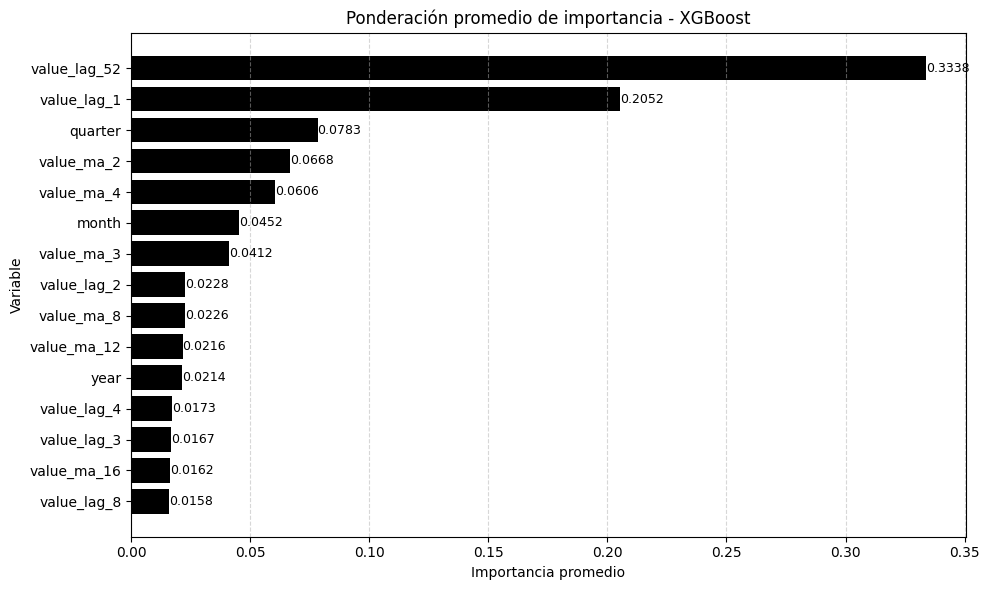

In [17]:
# Estadísticas promedio por variable
df_hist_avg_vars = (
    df_importancias
        .groupby("variable", as_index=False)["importancia"]
        .mean()
        .sort_values("importancia", ascending=False)
)

# filtrar importancia estrictamente positiva
df_hist_avg_vars = df_hist_avg_vars[df_hist_avg_vars["importancia"] > 0]

# opcional: tomar top 15 para que el gráfico sea legible (cantidad de variables)
top_k = 15
df_plot = df_hist_avg_vars.head(top_k)

plt.figure(figsize=(10, 6))
bars = plt.barh(df_plot["variable"], df_plot["importancia"], color="black")

# agregar valores numéricos al lado de cada barra
for i, v in enumerate(df_plot["importancia"]):
    plt.text(v, i, f"{v:.4f}", va="center", fontsize=9)

plt.gca().invert_yaxis()
plt.title("Ponderación promedio de importancia - XGBoost")
plt.xlabel("Importancia promedio")
plt.ylabel("Variable")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Ahora se muestra la asignación de los puntajes e importancia por fold

In [18]:
# matriz de importancias por fold
df_stats_by_folds = []

for i in range(n_splits):

    df_fold = df_importancias[
        (df_importancias["fold"] == i+1) &
        (df_importancias["importancia"] > 0.00)
    ]

    df_fold_matrix = (
        df_fold
        .pivot_table(
            index="fold",
            columns="variable",
            values="importancia",
            aggfunc="sum"
        )
        .reset_index()
    )

    df_stats_by_folds.append(df_fold_matrix)

# unir todos los folds
df_stats_by_folds = pd.concat(df_stats_by_folds, ignore_index=True)
df_stats_by_folds

variable,fold,month,quarter,value_lag_1,value_lag_12,value_lag_2,value_lag_3,value_lag_4,value_lag_52,value_lag_8,value_ma_12,value_ma_16,value_ma_2,value_ma_3,value_ma_4,value_ma_8,year
0,1,0.060691,0.039277,0.204162,0.012950,0.023202,0.013182,0.020613,0.370036,0.023802,0.020643,0.008504,0.045937,0.017406,0.099188,0.018614,0.021793
1,2,0.041569,0.134135,0.193077,0.011279,0.017881,0.011438,0.011271,0.365701,0.012826,0.021328,0.012257,0.041000,0.048998,0.033798,0.016361,0.027081
2,3,0.059492,0.086318,0.165045,0.012612,0.015773,0.023083,0.016084,0.348265,0.014130,0.018649,0.014195,0.083989,0.046966,0.064227,0.017886,0.013286
3,4,0.026736,0.050995,0.221320,0.018202,0.021242,0.013879,0.021425,0.365185,0.014915,0.025035,0.027660,0.075663,0.036204,0.036514,0.020799,0.024228
4,5,0.037759,0.080693,0.242397,0.017652,0.035832,0.021979,0.017283,0.219612,0.013130,0.022298,0.018426,0.087575,0.056233,0.069329,0.039378,0.020425


Se grafican los resultados y las asignaciones de puntaje por folds

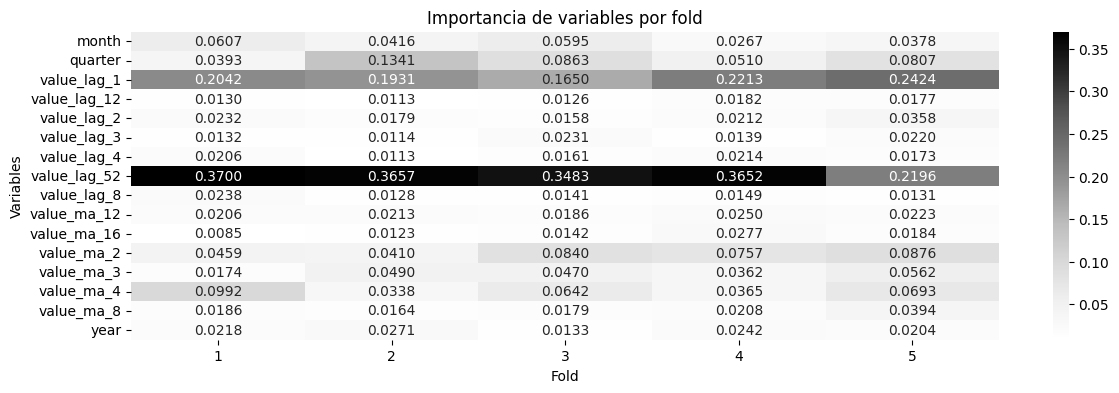

In [19]:

df_plot = df_stats_by_folds.set_index("fold")

plt.figure(figsize=(14,4))
sns.heatmap(df_plot.T, cmap="Greys", annot=True, fmt=".4f")
plt.title("Importancia de variables por fold")
plt.xlabel("Fold")
plt.ylabel("Variables")
plt.show()

Se organiza el df para que muestre lo spuntajes por fold como gráficas de barras

In [20]:
df_long = df_stats_by_folds.melt(
    id_vars=["fold"], 
    var_name="variable", 
    value_name="importancia"
).sort_values(by=["fold", "importancia"], ascending=[True, False])
df_long.head()

,fold,variable,importancia
35,1,value_lag_52,0.370036
10,1,value_lag_1,0.204162
65,1,value_ma_4,0.099188
0,1,month,0.060691
55,1,value_ma_2,0.045937


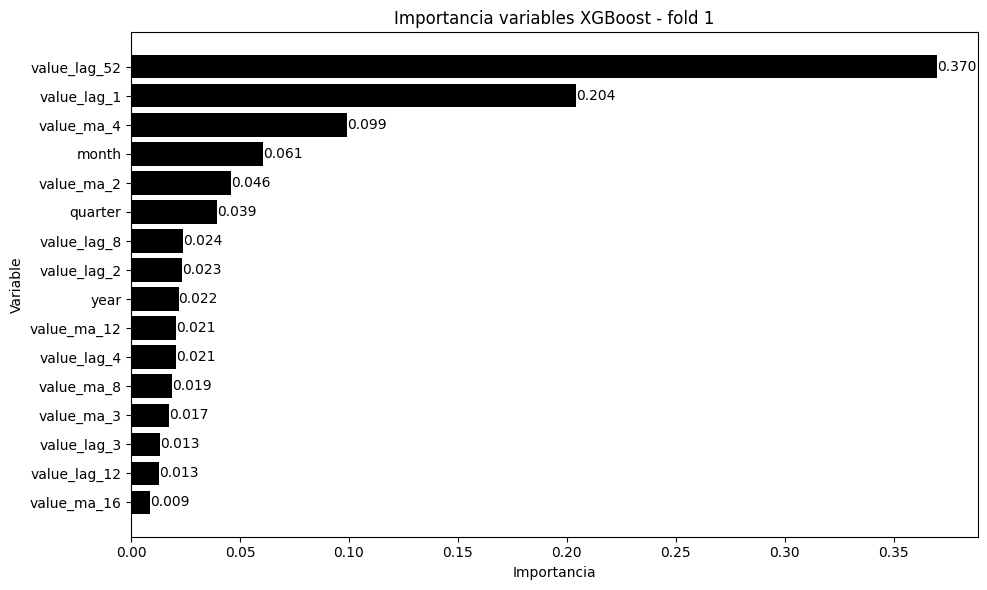

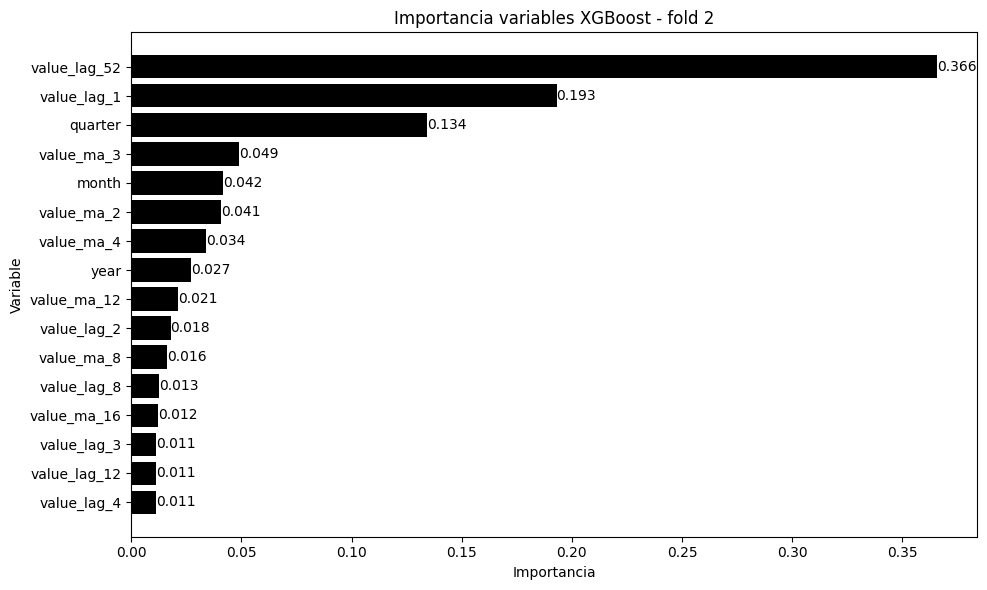

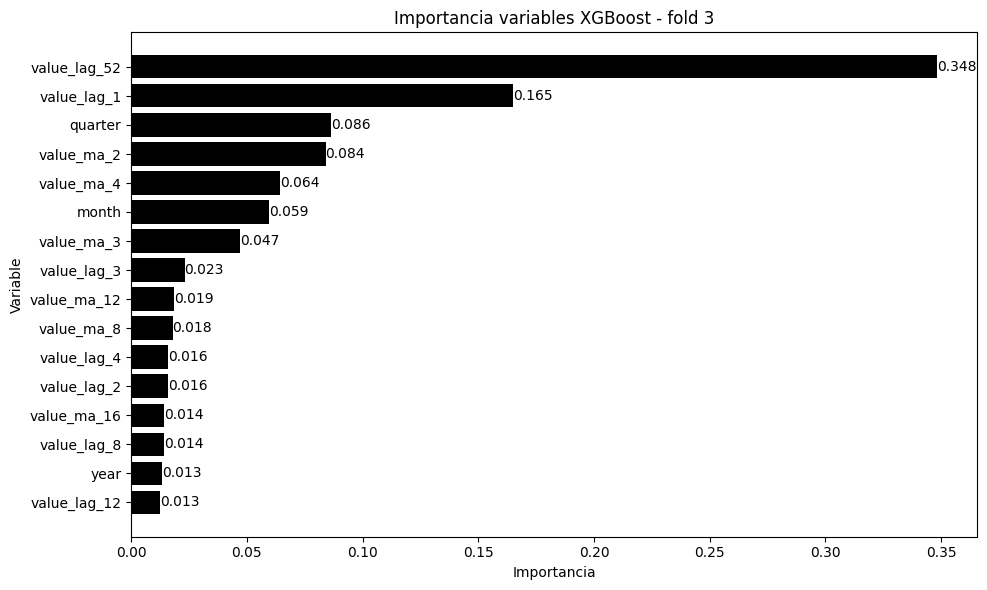

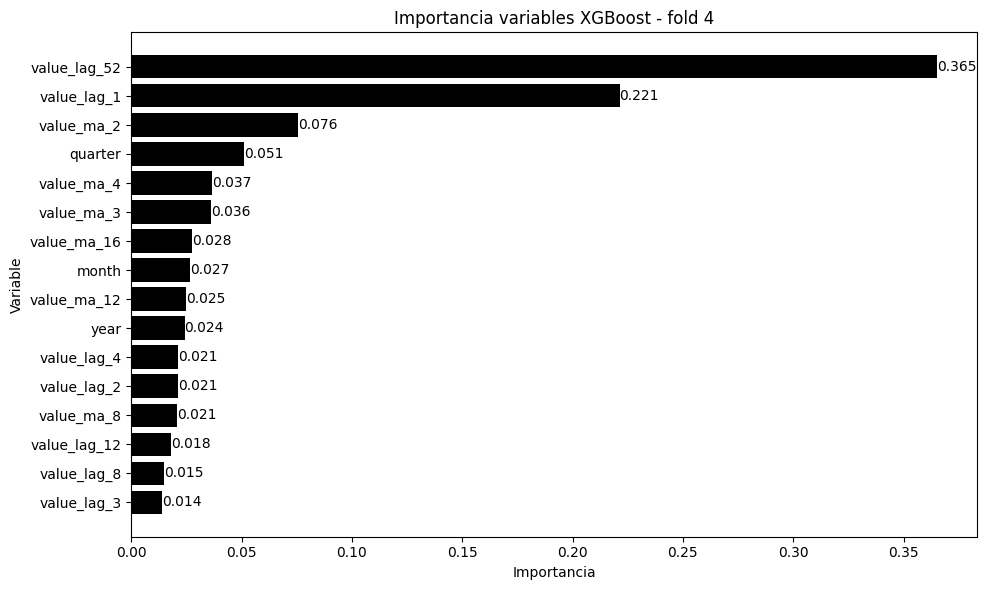

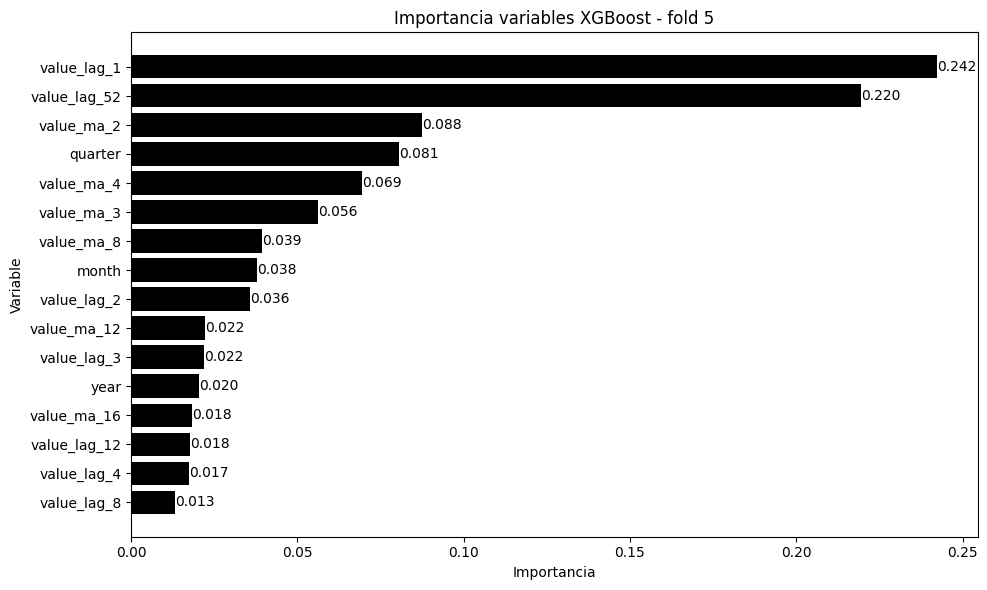

In [21]:
for fold in df_long["fold"].unique():
    df_fold = df_long[df_long["fold"] == fold]
    
    plt.figure(figsize=(10,6))
    bars = plt.barh(df_fold["variable"], df_fold["importancia"], color="black")
    plt.gca().invert_yaxis()
    
    plt.title(f"Importancia variables XGBoost - fold {fold}")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")

    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2, f"{width:.3f}", va="center")

    plt.tight_layout()
    plt.show()

se obtiene todo el listado de los trials ejecutados y se crea un df que muestra los errores por fold y por trial

In [22]:

# info de los trials 
# se extraen los trials
trials = study.get_trials()
# creación del df a nivel de registro
# el esquema del df se infiere a partir de las claves almacenadas en cada registro (las claves no varían, dado como se guardaron)
rows = [] # se usará para guardar la info a nivel de registro
for trial in trials:
    trial_number = trial.number # número de trial: trial 1, 2,...
    attrs = trial.user_attrs # los valores de las métricas se definen en la función como 
    # un atributo de usuario, definido como un diccionario
    # se recorren ahora las claves y los valores de cada diccionario
    for key, value in attrs.items():
        if key.startswith("fold_") and isinstance(value, dict): 
            # se examina si cada clave del diccionario empieza con fold_. Recordar que en la función
            # se guardó un diccionario con el nombre fold_i_metrics, que guarda la info de cada fold y cada trial.
            # Se mira entonces si la clave es de esa forma y si el valor de esa clave es un diccionario
            rows.append({
                "trial": trial_number,
                "fold": int(key.replace("fold_", "")),   # extraer número
                "mape": value["mape"],
                "mae": value["mae"],
                "rmse": value["rmse"],
                "smape": value["smape"]
            })

df_metrics = pd.DataFrame(rows)
df_metrics.head()


,trial,fold,mape,mae,rmse,smape
0,0,1,0.044134,55514.903361,70902.180012,0.042821
1,0,2,0.028915,40075.284314,52559.359813,0.029504
2,0,3,0.042985,54858.844888,77740.327235,0.041316
3,0,4,0.046979,58955.459034,73919.519535,0.046212
4,0,5,0.034077,43467.237045,52702.445701,0.034370


In [23]:
# descripción general del df de métricas
df_stats = df_metrics.describe()
df_stats[["mape", "mae", "rmse", "smape"]]

,mape,mae,rmse,smape
count,250.000000,250.000000,250.000000,250.000000
mean,0.037878,48548.570952,62861.885698,0.037342
std,0.006749,7474.121871,10052.940619,0.006100
min,0.025490,35265.205532,47050.225771,0.025931
25%,0.032073,41167.245711,51360.598970,0.032225
50%,0.038423,48769.580182,68019.438432,0.037092
75%,0.044659,56120.882703,71629.074593,0.043349
max,0.048749,61284.621499,79820.072564,0.047902


### Distribución por errores promedio
se muestran las distribuciones de los errores promedio por trial

In [24]:
df_metrics_avg = df_metrics.copy()
df_metrics_avg = df_metrics_avg.groupby(
    "trial", as_index=False 
)[["mape", "mae", "rmse", "smape"]].mean()
df_metrics_avg.head()

,trial,mape,mae,rmse,smape
0,0,0.039418,50574.345728,65564.766459,0.038845
1,1,0.038480,49538.409104,64165.462080,0.037929
2,2,0.038172,48947.616457,63437.040074,0.037629
3,3,0.038154,49045.371499,64263.959766,0.037546
4,4,0.038842,49872.009664,64436.456351,0.038269


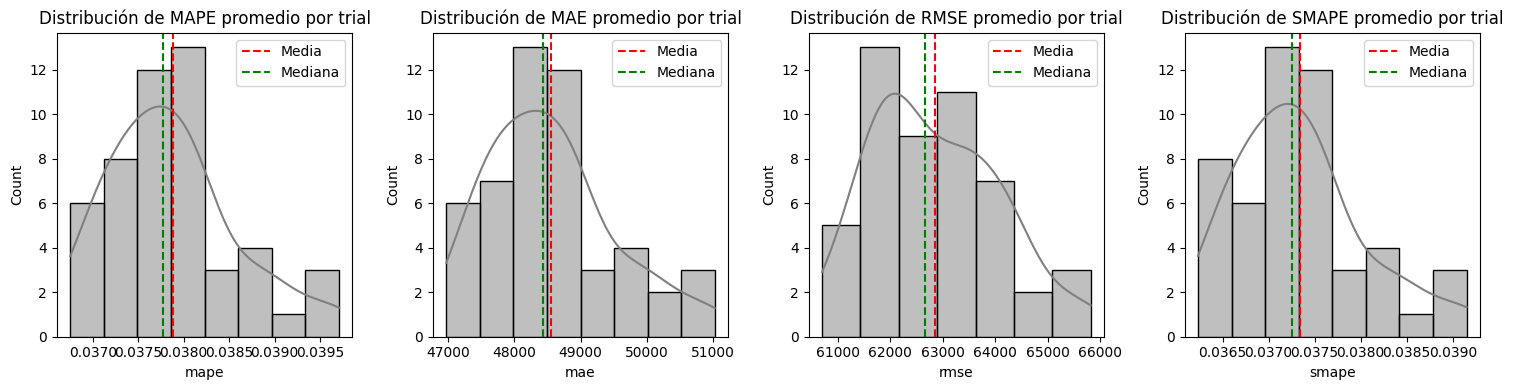

In [25]:
# distribución errores promedio por fold
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, metric in zip(axes, ["mape", "mae", "rmse", "smape"]):
    sns.histplot(df_metrics_avg[metric], kde=True, ax=ax, color="gray")
    ax.set_title(f"Distribución de {metric.upper()} promedio por trial")
    ax.axvline(df_metrics_avg[metric].mean(), color='red', linestyle='--', label='Media')
    ax.axvline(df_metrics_avg[metric].median(), color='green', linestyle='--', label='Mediana')
    ax.legend()

plt.tight_layout()
plt.show()

### Distribución de errores por fold y por trial
se muestran los valores de las métricas de error por cada fold y por cada trial

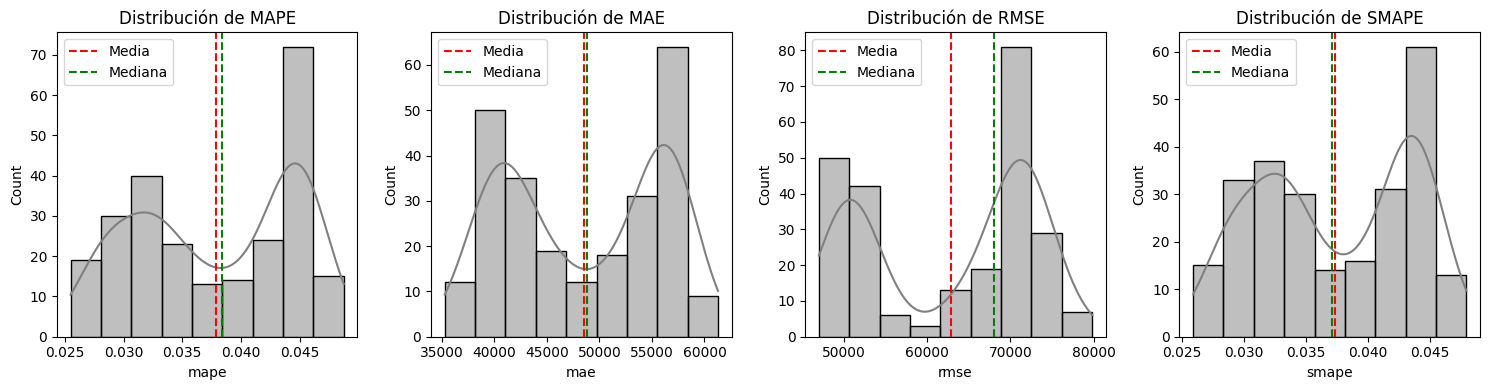

In [26]:
# histogramas de los errores por trial y por fold
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, metric in zip(axes, ["mape", "mae", "rmse", "smape"]):
    sns.histplot(df_metrics[metric], kde=True, ax=ax, color="gray")
    ax.set_title(f"Distribución de {metric.upper()}")
    ax.axvline(df_metrics[metric].mean(), color='red', linestyle='--', label='Media')
    ax.axvline(df_metrics[metric].median(), color='green', linestyle='--', label='Mediana')
    """ if metric == 'mape':
        medians_df['mape'] = df_metrics[metric].median() """
    ax.legend()

plt.tight_layout()
plt.show()


Se ordena por métrica 

In [27]:
# Ordenar por cada métrica para tomar los mejores conjuntos de parametros
df_mape_sorted = df_metrics.sort_values("mape", ascending=True).reset_index(drop=True)
df_mae_sorted = df_metrics.sort_values("mae", ascending=True).reset_index(drop=True)
df_rmse_sorted = df_metrics.sort_values("rmse", ascending=True).reset_index(drop=True)
df_smape_sorted = df_metrics.sort_values("smape", ascending=True).reset_index(drop=True)

print("Mejores Folds por MAPE:")
print(df_mape_sorted.tail())

print("\Mejores Folds por MAE:")
print(df_mae_sorted.tail())

print("\Mejores Folds por RMSE:")
print(df_rmse_sorted.tail())

print("\Mejores Folds por sMAPE:")
print(df_smape_sorted.tail())

Mejores Folds por MAPE:
     trial  fold      mape           mae          rmse     smape
245      0     4  0.046979  58955.459034  73919.519535  0.046212
246     24     4  0.047135  59062.927871  73988.924035  0.046304
247     44     4  0.047700  59660.074230  74271.083227  0.046723
248     29     4  0.047855  59911.805322  74214.952980  0.047059
249     37     4  0.048749  61284.621499  76577.216195  0.047902
\Mejores Folds por MAE:
     trial  fold      mape           mae          rmse     smape
245     24     4  0.047135  59062.927871  73988.924035  0.046304
246      1     3  0.046440  59610.741246  79820.072564  0.044713
247     44     4  0.047700  59660.074230  74271.083227  0.046723
248     29     4  0.047855  59911.805322  74214.952980  0.047059
249     37     4  0.048749  61284.621499  76577.216195  0.047902
\Mejores Folds por RMSE:
     trial  fold      mape           mae          rmse     smape
245      3     3  0.043569  55742.267507  77547.133666  0.041924
246      0     3 

Se crea df que obtiene los hiperparametros por fold junto con las metricas asociadas, se toman los 3 que dejan menor mape promedio para comparar y luego se toma uno solo

In [28]:
df_trials = {   
    "trial" :[],
    "n_estimators": [],
    "max_depth": [],
    "learning_rate": [],
    "min_child_weight": [] ,
    "gamma": [],
    "reg_lambda" : [],
    "reg_alpha" : [],
    "subsample" : [],
    "colsample_bytree": [],
    "mape_mean": [],
    "mae_mean": [],
    "rmse_mean": [],
    "smape_mean": []
}

for trial in trials:
    for key in df_trials.keys():

        if key == "trial":
            df_trials[key].append(trial.number)

        elif key in ["mape_mean", "mae_mean", "rmse_mean", "smape_mean"]:
            df_trials[key].append(round(trial.user_attrs[key],6))

        else: 
            df_trials[key].append(round(trial.params[key],5))
   
df_params_models = pd.DataFrame(df_trials)
df_params_models = df_params_models.sort_values("mape_mean") # se ordenan conjuntos de hiperparametros que dejan menor mape promedio y se toma
# el menor
df_params_models.head(3)

,trial,n_estimators,max_depth,learning_rate,min_child_weight,gamma,reg_lambda,reg_alpha,subsample,colsample_bytree,mape_mean,mae_mean,rmse_mean,smape_mean
24,24,420,7,0.04925,6.28181,0.56290,2.56313,3.65806,0.75597,0.60617,0.036752,46976.509454,60700.594914,0.036232
13,13,599,6,0.03891,5.07421,0.54026,3.47055,3.17371,0.82792,0.61062,0.036869,47189.960014,60930.521754,0.036349
41,41,337,7,0.05716,7.47679,0.53366,1.67641,3.02818,0.60592,0.69549,0.036918,47400.652801,62264.731638,0.036454


In [29]:
# se exporta el df con los mejores modelos 
df_params_models.head(3).to_csv("../../../data/best_train_models/best_models_xgboost.csv")

In [30]:
# organización de hiperparametros
# Corrección
params_xgb = {
    k: v 
    for k, v in study.best_params.items() 
    if k != 'lag'
}
study.best_params

# La variable params_xgb contendrá solo los hiperparámetros de XGBoost
# (n_estimators, max_depth, learning_rate, etc.),

{'n_estimators': 420,
 'max_depth': 7,
 'learning_rate': 0.04924728725460317,
 'min_child_weight': 6.28181175558134,
 'gamma': 0.5628956200652583,
 'reg_lambda': 2.5631300054321633,
 'reg_alpha': 3.6580607862443353,
 'subsample': 0.7559702553281903,
 'colsample_bytree': 0.6061659318733446}

In [31]:
len(X_val)

51

In [32]:
# se fija el modelo con los mejores hiperparametros con los datos finales, se hacen la prediccione y se examinan los errores oos
best_model = build_xgboost_regressor(**params_xgb, nthreads=1)
best_model.fit(X_folds, y_folds)
y_pred = best_model.predict(X_val)

# metricas de error 

mape_val = mean_absolute_percentage_error(y_val, y_pred)
mae_val  = mean_absolute_error(y_val, y_pred)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred))
smape_calc_val = MeanAbsolutePercentageError(symmetric=True) 
smape_val = smape_calc_val(y_val, y_pred)

print(f"mape validación: {mape_val*100:.4f}%")
print(f"mae validación: {mae_val}")
print(f"rmse validación: {rmse_val}")
print(f"smape validación: {smape_val*100:.4f}")

mape validación: 2.4728%
mae validación: 31344.583984375
rmse validación: 39781.38821107177
smape validación: 2.4733


In [33]:

importance = best_model.get_booster().get_score(importance_type="gain")

total = sum(importance.values())

importance_norm = {k: v / total for k, v in importance.items()}

importance_norm

{'year': 0.025625172687071297,
 'month': 0.03429374517705352,
 'quarter': 0.06576344972208056,
 'value_lag_1': 0.2021513496841248,
 'value_lag_2': 0.019189804089341088,
 'value_lag_3': 0.01633305023723141,
 'value_lag_4': 0.012902090822546152,
 'value_lag_8': 0.018251130489658884,
 'value_lag_12': 0.012869467653427717,
 'value_lag_52': 0.2723264067643855,
 'value_ma_2': 0.10802460056045002,
 'value_ma_3': 0.08442381770397694,
 'value_ma_4': 0.06618021971266506,
 'value_ma_8': 0.025270068184595276,
 'value_ma_12': 0.019162601635160603,
 'value_ma_16': 0.017233024876231174}

In [34]:
y_folds

,value
0,1.344112e+06
1,1.354987e+06
2,1.267394e+06
3,1.288666e+06
4,1.332559e+06
...,...
451,1.422410e+06
452,1.333686e+06
453,1.150707e+06
454,1.270610e+06


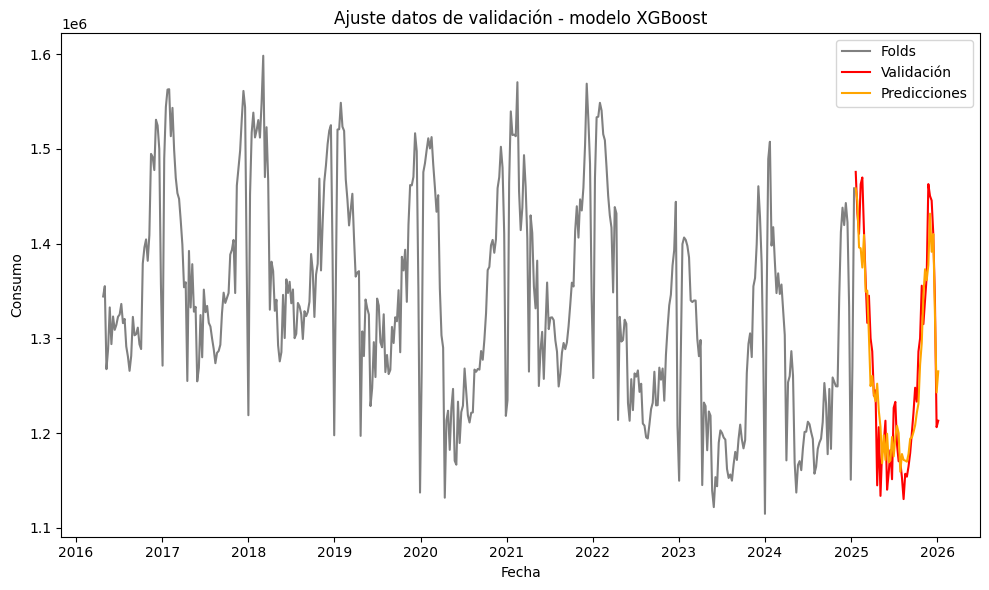

In [35]:
# ajute visual 
plt.figure(figsize=(10,6))
plt.plot(X_folds.index, y_folds , label="Folds", color="gray")
plt.plot(X_val.index, y_val, label="Validación", color="red")
plt.plot(X_val.index[-len(y_pred):], y_pred, label="Predicciones", color="orange")
plt.title("Ajuste datos de validación - modelo XGBoost")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
#plt.grid(True)
plt.legend()
plt.tight_layout()

Se exportan las predicciones en json para poder calcular luego la predicción conjunta

In [36]:
df_data_close[folds_data_size:]["Start date"]

456   2025-01-20
457   2025-01-27
458   2025-02-03
459   2025-02-10
460   2025-02-17
461   2025-02-24
462   2025-03-03
463   2025-03-10
464   2025-03-17
465   2025-03-24
466   2025-03-31
467   2025-04-07
468   2025-04-14
469   2025-04-21
470   2025-04-28
471   2025-05-05
472   2025-05-12
473   2025-05-19
474   2025-05-26
475   2025-06-02
476   2025-06-09
477   2025-06-16
478   2025-06-23
479   2025-06-30
480   2025-07-07
481   2025-07-14
482   2025-07-21
483   2025-07-28
484   2025-08-04
485   2025-08-11
486   2025-08-18
487   2025-08-25
488   2025-09-01
489   2025-09-08
490   2025-09-15
491   2025-09-22
492   2025-09-29
493   2025-10-06
494   2025-10-13
495   2025-10-20
496   2025-10-27
497   2025-11-03
498   2025-11-10
499   2025-11-17
500   2025-11-24
501   2025-12-01
502   2025-12-08
503   2025-12-15
504   2025-12-22
505   2025-12-29
506   2026-01-05
Name: Start date, dtype: datetime64[ns]

In [37]:
arr_preds = []
for index, value in enumerate(df_data_close[folds_data_size:]["Start date"]):
    dict_pred = {
        "Date": value.strftime("%Y-%m-%d"), # convierte a la fecha a string para poder exportar a json
        "pred" : float(y_pred[index])
    }
    arr_preds.append(dict_pred)
arr_preds

[{'Date': '2025-01-20', 'pred': 1458093.375},
 {'Date': '2025-01-27', 'pred': 1444869.75},
 {'Date': '2025-02-03', 'pred': 1395853.5},
 {'Date': '2025-02-10', 'pred': 1394908.375},
 {'Date': '2025-02-17', 'pred': 1374644.125},
 {'Date': '2025-02-24', 'pred': 1409041.75},
 {'Date': '2025-03-03', 'pred': 1349080.625},
 {'Date': '2025-03-10', 'pred': 1350309.75},
 {'Date': '2025-03-17', 'pred': 1301910.375},
 {'Date': '2025-03-24', 'pred': 1249500.375},
 {'Date': '2025-03-31', 'pred': 1260132.375},
 {'Date': '2025-04-07', 'pred': 1241057.625},
 {'Date': '2025-04-14', 'pred': 1233518.125},
 {'Date': '2025-04-21', 'pred': 1252059.375},
 {'Date': '2025-04-28', 'pred': 1223202.0},
 {'Date': '2025-05-05', 'pred': 1206595.75},
 {'Date': '2025-05-12', 'pred': 1168068.125},
 {'Date': '2025-05-19', 'pred': 1197681.25},
 {'Date': '2025-05-26', 'pred': 1171530.75},
 {'Date': '2025-06-02', 'pred': 1199229.875},
 {'Date': '2025-06-09', 'pred': 1169000.375},
 {'Date': '2025-06-16', 'pred': 1170971.125}

In [38]:
# Cálculo de métricas agregadas
dict_to_export = {
    "mape_val": float(mape_val),
    "mae_val": float(mae_val),
    "smape_val": float(smape_val),
    "rmse_val": float(rmse_val),
    "predictions": arr_preds
}
with open ("../../../data/preds_energy_models/xgboost_preds.json", "w") as json_file:
    json.dump(dict_to_export, json_file, indent=4)